In [112]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from scipy.stats import ks_2samp
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV

In [113]:
df_path = Path(f"{os.getcwd()}/../data/preprocessed_train.csv")
df = pd.read_csv(df_path)

In [114]:
df.head()

,Unnamed: 0,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,HOUSETYPE_MODE_block of flats,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,FLAG_OWN_CAR_Y
0,71,100083,0,0,103500.0,573628.5,24435.0,463500.0,0.009657,-15406,...,1,0,0,0,1,1,0,1,0,1
1,124,100145,0,1,202500.0,260725.5,16789.5,198000.0,0.018850,-16282,...,1,0,0,0,1,1,0,1,0,1
2,143,100165,0,0,175500.0,1293502.5,35568.0,1129500.0,0.018850,-21961,...,1,0,0,0,1,1,0,1,0,1
3,152,100179,0,0,202500.0,675000.0,53329.5,675000.0,0.031329,-11375,...,1,0,0,1,0,1,0,1,0,1
4,161,100190,0,0,162000.0,263686.5,24781.5,238500.0,0.022625,-13972,...,1,0,0,1,0,1,0,1,0,1


In [115]:
# split into features and target
X, y = df.drop(columns=['TARGET', 'SK_ID_CURR', 'Unnamed: 0']), df['TARGET']

# the target column is not a feature, the SK_ID_CURR is an identifier, and the AGE_BUCKET is not numerical

# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Define a function to evaluate the model

What to include:
- Best F1 threshold score
- KS statistic
- AUPRC (average precision)
- AUROC
- Gini

In [116]:
# function will take trained model, along with test data, and produce dataframe with results

def evaluate_model(algorithm, model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    # auroc
    auroc = roc_auc_score(y_test, y_prob)
    # gini
    gini = (2 * auroc) - 1
    # ks
    ks = ks_2samp(y_prob[y_test == 0], y_prob[y_test == 1]).statistic
    # auprc
    auprc = average_precision_score(y_test, y_prob)
    # optimal threshold for f1
    thresholds = np.arange(0.01, 1.00, 0.01)
    best_threshold = 0.5
    best_f1 = 0

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        f1 = f1_score(y_test, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    # get info to be able to plot ROC and PR curves
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
    precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

    return {
        "Model": algorithm,
        "AUROC": auroc,
        "Gini": gini,
        "KS": ks,
        "AUPRC": auprc,
        "Best Threshold": best_threshold,
        "F1": best_f1,
        "ROC Curve": (fpr, tpr, roc_thresholds),
        "PR Curve": (precision, recall, pr_thresholds)
    }

In [117]:
def display_results(results):
    display({k: v for k, v in results.items() if k not in ['ROC Curve', 'PR Curve']})

### Create Pipeline 

In [118]:
numeric_cols = X_train.select_dtypes(include="number").columns

# numeric columns will be standardized
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols)]
)

### Logistic Regression Baseline

In [119]:
lr_pipeline = Pipeline(
    [('preprocesser', preprocessor),
    ('model', LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced'))
    ]
)

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesser', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](260,)","['CNT_CHILDREN','AMT_INCOME_TOTAL','AMT_CREDIT',..., 'NAME_CONTRACT_TYPE_Cash loans','NAME_CONTRACT_TYPE_Revolving loans', 'FLAG_OWN_CAR_Y']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,260
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``

In [120]:
lr_results = evaluate_model("Logistic Regression", lr_pipeline, X_test, y_test)
display_results(lr_results)

{'Model': 'Logistic Regression',
 'AUROC': 0.7347894449001914,
 'Gini': 0.46957888980038276,
 'KS': np.float64(0.37202099240655445),
 'AUPRC': 0.19258911283291544,
 'Best Threshold': np.float64(0.8),
 'F1': 0.26973684210526316}

### Random Forest

In [121]:
random_forest_pipeline = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced'))
    ]
)

random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](260,)","['CNT_CHILDREN','AMT_INCOME_TOTAL','AMT_CREDIT',..., 'NAME_CONTRACT_TYPE_Cash loans','NAME_CONTRACT_TYPE_Revolving loans', 'FLAG_OWN_CAR_Y']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,260
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``

In [122]:
rf_results = evaluate_model("Random Forest", random_forest_pipeline, X_test, y_test)
display_results(rf_results)

{'Model': 'Random Forest',
 'AUROC': 0.7403478050524811,
 'Gini': 0.4806956101049622,
 'KS': np.float64(0.37305168170631664),
 'AUPRC': 0.15960286156699408,
 'Best Threshold': np.float64(0.5),
 'F1': 0.24421052631578946}

### XGBoost

In [123]:
xgboost_pipeline = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(n_estimators=200, max_depth=20, scale_pos_weight=1))
    ]
)

xgboost_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](260,)","['CNT_CHILDREN','AMT_INCOME_TOTAL','AMT_CREDIT',..., 'NAME_CONTRACT_TYPE_Cash loans','NAME_CONTRACT_TYPE_Revolving loans', 'FLAG_OWN_CAR_Y']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,260
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``

In [124]:
xgboost_results = evaluate_model("XGBoost", xgboost_pipeline, X_test, y_test)
display_results(xgboost_results)

{'Model': 'XGBoost',
 'AUROC': 0.7169364338150228,
 'Gini': 0.4338728676300456,
 'KS': np.float32(0.31020066),
 'AUPRC': 0.1745898272767852,
 'Best Threshold': np.float64(0.02),
 'F1': 0.2553191489361702}

### Comparison table of all models + all results

In [125]:
comparison_df = pd.DataFrame([lr_results, rf_results, xgboost_results]).drop(columns=['ROC Curve', 'PR Curve'])
display(comparison_df)

,Model,AUROC,Gini,KS,AUPRC,Best Threshold,F1
0,Logistic Regression,0.734789,0.469579,0.372021,0.192589,0.80,0.269737
1,Random Forest,0.740348,0.480696,0.373052,0.159603,0.50,0.244211
2,XGBoost,0.716936,0.433873,0.310201,0.174590,0.02,0.255319


Random Forest wins on AUROC (by the slightest margin), and baseline Logistic Regression wins on AUPRC

### Plotting curves

#### First figure - ROC curve

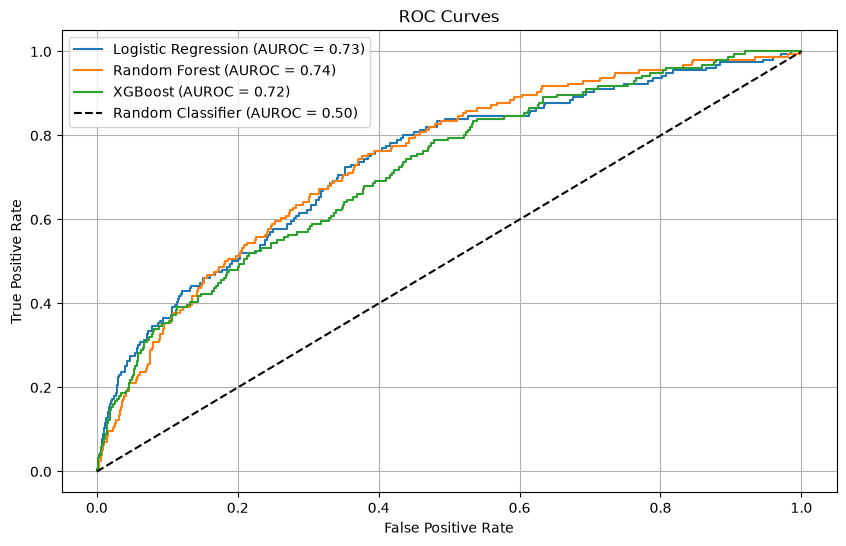

In [126]:
def plot_roc_curves():
    plt.figure(figsize=(10, 6))
    for results in [lr_results, rf_results, xgboost_results]:
        fpr, tpr, _ = results['ROC Curve']
        plt.plot(fpr, tpr, label=f"{results['Model']} (AUROC = {results['AUROC']:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUROC = 0.50)')
    plt.title('ROC Curves')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

plot_roc_curves()

#### Second figure - Precision Recall Curve

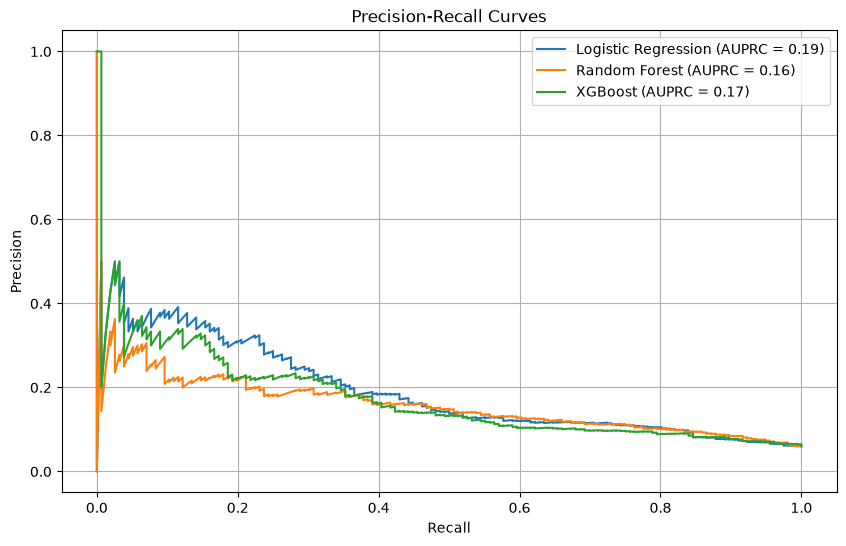

In [127]:
def plot_precision_recall_curves():
    plt.figure(figsize=(10, 6))
    for results in [lr_results, rf_results, xgboost_results]:
        precision, recall, _ = results['PR Curve']
        plt.plot(recall, precision, label=f"{results['Model']} (AUPRC = {results['AUPRC']:.2f})")
    plt.title('Precision-Recall Curves')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()

plot_precision_recall_curves()

### Stratified K-Fold CV

Here we will use cross-validation to determine the best model. This involves training each model across 5 folds (splits), then taking the mean and std of AUROC across folds

In [128]:
pipelines = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': random_forest_pipeline,
    'XGBoost': xgboost_pipeline
}

# define one cv object and use across all pipelines so that differences are due to the models and not the data
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kfolds_cv_results = {}

In [129]:
def cross_validate(results_dict, pipelines, X_train, y_train, cv_object):
    for name, pipeline in pipelines.items():
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv_object, scoring='roc_auc')
        results_dict[name] = {
            'Mean AUROC': np.mean(scores),
            'Std AUROC': np.std(scores)
        }

cross_validate(kfolds_cv_results, pipelines, X, y, cv)

In [130]:
kfolds_cv_results

{'Logistic Regression': {'Mean AUROC': np.float64(0.7187722595293012),
  'Std AUROC': np.float64(0.01695574112497582)},
 'Random Forest': {'Mean AUROC': np.float64(0.7335869114648468),
  'Std AUROC': np.float64(0.013567486438540445)},
 'XGBoost': {'Mean AUROC': np.float64(0.7006286339875145),
  'Std AUROC': np.float64(0.01780878573198198)}}

It appears that the Random Forest classifier performs the best across the three models. Not only does it have the highest AUROC, it also has the lowest standard deviation. This will be our "champion" model moving forward

### RandomizedSearchCV

In [131]:
# define search paramters for random forest

param_dist = {
    "model__n_estimators": [100, 200, 300, 500], # number of trees
    "model__max_depth": [3, 5, 10, None], # max depth from root to leaves
    "model__min_samples_split": [2, 5, 10], # minimum number of samples required to split an internal node
    "model__min_samples_leaf": [1, 2, 5], # minimum number of samples required to be at a leaf node
    "model__max_features": ["sqrt", "log2"] # maximum number of features to consider when looking for the best split
}

search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [132]:
search.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...mators=200))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [3, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a b

In [133]:
print("Best AUROC:", search.best_score_)
print("Best params:", search.best_params_)

Best AUROC: 0.7438059521964023
Best params: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': None}


### Saving the model using joblib

In [134]:
import joblib
model_path = Path(f"{os.getcwd()}/../models/best_model.pkl")
joblib.dump(search.best_estimator_, model_path)

['c:\\Users\\alann\\OneDrive\\Desktop\\Coding\\Jarvis Talent Incubation Training\\jarvis_data_eng_AlanHu\\machine_learning\\module1\\capstone\\notebooks\\..\\models\\best_model.pkl']